In [2]:
import sys, os

def find_backend_folder(start_path, max_levels=5):
    current = os.path.abspath(start_path)
    for _ in range(max_levels):
        candidate = os.path.join(current, "backend")
        if os.path.isdir(candidate) and os.path.isfile(os.path.join(candidate, "app.py")):
            return candidate
        parent = os.path.dirname(current)
        if parent == current:
            break
        current = parent
    return None

backend_path = find_backend_folder(os.getcwd())
if backend_path and backend_path not in sys.path:
    sys.path.insert(0, backend_path)
print("Backend path:", backend_path)

import numpy as np
import pandas as pd
import pymc as pm # type: ignore
import arviz as az # type: ignore
import matplotlib.pyplot as plt

from services.data_loader import load_prices, load_events

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 5)

Backend path: /home/sumeya/Documents/ai project/brent-oil-change-point-analysis/backend


In [3]:
prices = load_prices()
prices["log_return"] = np.log(prices["Price"]) - np.log(prices["Price"].shift(1))
prices = prices.dropna(subset=["log_return"]).reset_index(drop=True)

print(f"{len(prices)} daily log returns, {prices['Date'].min().date()} to {prices['Date'].max().date()}")
prices.head()

9010 daily log returns, 1987-05-21 to 2022-11-14


,Date,Price,log_return
0,1987-05-21,18.45,-0.009709
1,1987-05-22,18.55,0.005405
2,1987-05-25,18.60,0.002692
3,1987-05-26,18.63,0.001612
4,1987-05-27,18.60,-0.001612


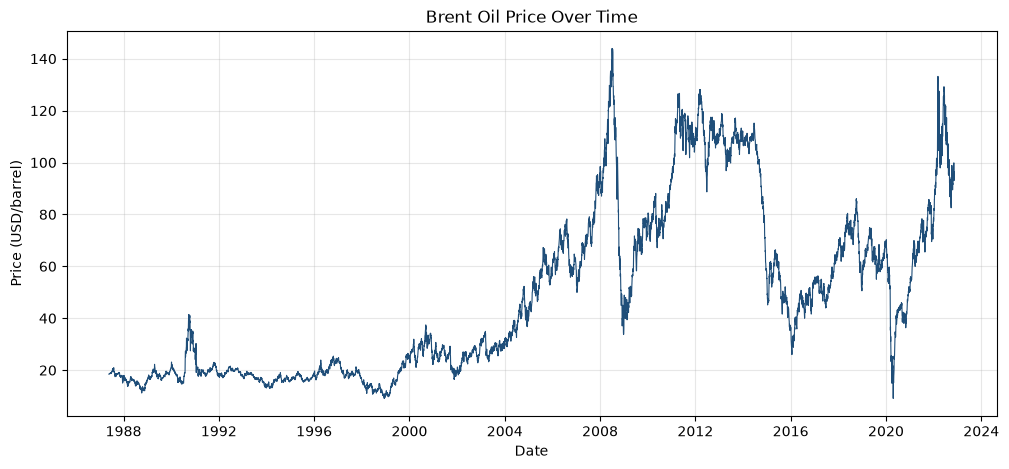

In [4]:
plt.plot(prices["Date"], prices["Price"], linewidth=0.8, color="#1F4E79")
plt.title("Brent Oil Price Over Time")
plt.xlabel("Date"); plt.ylabel("Price (USD/barrel)")
plt.grid(alpha=0.3)
plt.show()

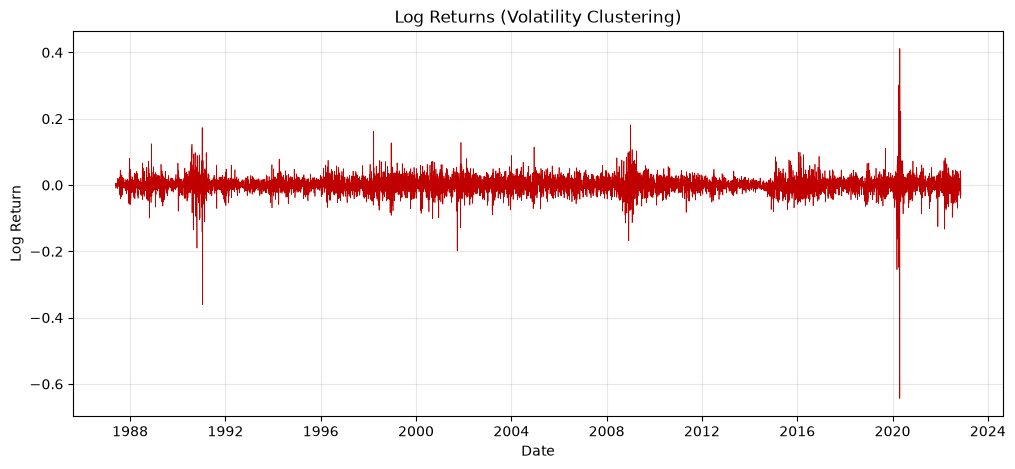

In [5]:
plt.plot(prices["Date"], prices["log_return"], linewidth=0.5, color="#C00000")
plt.title("Log Returns (Volatility Clustering)")
plt.xlabel("Date"); plt.ylabel("Log Return")
plt.grid(alpha=0.3)
plt.show()

In [6]:
import sys
import numpy

print("Python:")
print(sys.executable)

print("NumPy version:")
print(numpy.__version__)

print("NumPy location:")
print(numpy.__file__)

Python:
/home/sumeya/Documents/ai project/brent-oil-change-point-analysis/.venv/bin/python
NumPy version:
2.4.6
NumPy location:
/home/sumeya/Documents/ai project/brent-oil-change-point-analysis/.venv/lib/python3.12/site-packages/numpy/__init__.py


In [7]:
import sys

!"{sys.executable}" -m pip uninstall -y numpy numba
!"{sys.executable}" -m pip install numpy==2.4.6 numba==0.65.1

Found existing installation: numpy 2.4.6
Uninstalling numpy-2.4.6:
  Successfully uninstalled numpy-2.4.6
Found existing installation: numba 0.65.1
Uninstalling numba-0.65.1:
  Successfully uninstalled numba-0.65.1
  Using cached numpy-2.4.6-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached numba-0.65.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.9 kB)
Using cached numpy-2.4.6-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)
Using cached numba-0.65.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (3.8 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [numba]32m1/2 [numba]


In [8]:
import sys

print(sys.executable)

!"{sys.executable}" -m pip uninstall -y numpy numba
!"{sys.executable}" -m pip install --no-cache-dir numpy==2.4.6 numba==0.65.1

/home/sumeya/Documents/ai project/brent-oil-change-point-analysis/.venv/bin/python
Found existing installation: numpy 2.4.6
Uninstalling numpy-2.4.6:
  Successfully uninstalled numpy-2.4.6
Found existing installation: numba 0.65.1
Uninstalling numba-0.65.1:
  Successfully uninstalled numba-0.65.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 2.9 MB/s  0:00:06 eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 5.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [numba]32m1/2 [numba]


In [9]:
import sys
import subprocess

print("Python:", sys.executable)

subprocess.run([sys.executable, "-m", "pip", "show", "numpy"])
subprocess.run([sys.executable, "-m", "pip", "show", "numba"])
subprocess.run([sys.executable, "-m", "pip", "show", "pymc"])

Python: /home/sumeya/Documents/ai project/brent-oil-change-point-analysis/.venv/bin/python
Name: numpy
Version: 2.4.6
Summary: Fundamental package for array computing in Python
Home-page: https://numpy.org
Author: Travis E. Oliphant et al.
Author-email: 
License-Expression: BSD-3-Clause AND 0BSD AND MIT AND Zlib AND CC0-1.0
Location: /home/sumeya/Documents/ai project/brent-oil-change-point-analysis/.venv/lib/python3.12/site-packages
Requires: 
Required-by: arviz-base, arviz-stats, contourpy, matplotlib, numba, pandas, patsy, pymc, pytensor, scipy, statsmodels, xarray, xarray-einstats
Name: numba
Version: 0.65.1
Summary: compiling Python code using LLVM
Home-page: https://numba.pydata.org
Author: 
Author-email: 
License: BSD
Location: /home/sumeya/Documents/ai project/brent-oil-change-point-analysis/.venv/lib/python3.12/site-packages
Requires: llvmlite, numpy
Required-by: pytensor
Name: pymc
Version: 6.1.0
Summary: Probabilistic Programming in Python: Bayesian Modeling and Probabilistic

CompletedProcess(args=['/home/sumeya/Documents/ai project/brent-oil-change-point-analysis/.venv/bin/python', '-m', 'pip', 'show', 'pymc'], returncode=0)

In [10]:
prices = load_prices()
prices["log_return"] = np.log(prices["Price"]) - np.log(prices["Price"].shift(1))
prices = prices.dropna(subset=["log_return"]).reset_index(drop=True)

print(f"{len(prices)} daily log returns, {prices['Date'].min().date()} to {prices['Date'].max().date()}")
prices.head()

9010 daily log returns, 1987-05-21 to 2022-11-14


,Date,Price,log_return
0,1987-05-21,18.45,-0.009709
1,1987-05-22,18.55,0.005405
2,1987-05-25,18.60,0.002692
3,1987-05-26,18.63,0.001612
4,1987-05-27,18.60,-0.001612


In [11]:
log_returns = prices["log_return"].values
n = len(log_returns)

with pm.Model() as model:
    tau = pm.DiscreteUniform("tau", lower=0, upper=n - 1)
    mu1 = pm.Normal("mu1", mu=0, sigma=0.05)
    mu2 = pm.Normal("mu2", mu=0, sigma=0.05)
    sigma = pm.HalfNormal("sigma", sigma=0.05)

    idx = np.arange(n)
    mu = pm.math.switch(idx >= tau, mu2, mu1)

    likelihood = pm.Normal("likelihood", mu=mu, sigma=sigma, observed=log_returns)

    idata = pm.sample(draws=3000, tune=3000, chains=4, cores=1,
                       target_accept=0.9, return_inferencedata=True)

Sequential sampling (4 chains in 1 job)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu1, mu2, sigma]


Output()

Sampling 4 chains for 3_000 tune and 3_000 draw iterations (12_000 + 12_000 draws total) took 266 seconds.
There were 961 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [12]:
# Focused window: COVID-19 period
window_prices = load_prices()
window_prices = window_prices[(window_prices["Date"] >= "2019-06-01") & (window_prices["Date"] <= "2020-12-31")]
window_prices["log_return"] = np.log(window_prices["Price"]) - np.log(window_prices["Price"].shift(1))
window_prices = window_prices.dropna(subset=["log_return"]).reset_index(drop=True)

print(f"{len(window_prices)} days, {window_prices['Date'].min().date()} to {window_prices['Date'].max().date()}")

407 days, 2019-06-04 to 2020-12-31


In [13]:
log_returns = window_prices["log_return"].values
n = len(log_returns)

with pm.Model() as model_window:
    tau = pm.DiscreteUniform("tau", lower=0, upper=n - 1)
    mu1 = pm.Normal("mu1", mu=0, sigma=0.05)
    mu2 = pm.Normal("mu2", mu=0, sigma=0.05)
    sigma = pm.HalfNormal("sigma", sigma=0.05)

    idx = np.arange(n)
    mu = pm.math.switch(idx >= tau, mu2, mu1)

    likelihood = pm.Normal("likelihood", mu=mu, sigma=sigma, observed=log_returns)

    idata_window = pm.sample(draws=3000, tune=3000, chains=4, cores=1,
                              target_accept=0.95, return_inferencedata=True)

Sequential sampling (4 chains in 1 job)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu1, mu2, sigma]


Output()

Sampling 4 chains for 3_000 tune and 3_000 draw iterations (12_000 + 12_000 draws total) took 191 seconds.
There were 29 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [14]:
summary_window = az.summary(idata_window, var_names=["tau", "mu1", "mu2", "sigma"])
print(summary_window)

          mean       sd eti89_lb eti89_ub  ess_bulk  ess_tail r_hat mcse_mean  \
tau      2e+02      113       13      390       380       500  1.09       5.9   
mu1    -0.0027     0.01   -0.013   0.0083       349       791  1.03   0.00028   
mu2      0.003    0.008  -0.0065    0.014       142       805  1.03   0.00057   
sigma  0.05833  0.00209    0.055    0.062      4523      5348  1.00   3.1e-05   

       mcse_sd  
tau        3.3  
mu1    0.00082  
mu2    0.00093  
sigma  2.3e-05  


In [15]:
window_prices = load_prices()
window_prices = window_prices[(window_prices["Date"] >= "2020-01-01") & (window_prices["Date"] <= "2020-06-30")]

In [16]:
idata_window = pm.sample(draws=3000, tune=5000, chains=4, cores=1,
                          target_accept=0.99, return_inferencedata=True,
                          model=model_window)

Sequential sampling (4 chains in 1 job)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu1, mu2, sigma]


Output()

Sampling 4 chains for 5_000 tune and 3_000 draw iterations (20_000 + 12_000 draws total) took 111 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


In [17]:
summary_window = az.summary(idata_window, var_names=["tau", "mu1", "mu2", "sigma"])
print(summary_window)

          mean       sd eti89_lb eti89_ub  ess_bulk  ess_tail r_hat mcse_mean  \
tau      2e+02      113       12      390       465       603  1.04       5.3   
mu1    -0.0027     0.01   -0.013   0.0082       452      1122  1.01   0.00036   
mu2     0.0035    0.008  -0.0066    0.015       458      1198  1.01   0.00034   
sigma  0.05834  0.00209    0.055    0.062      4703      5127  1.00   3.1e-05   

       mcse_sd  
tau          3  
mu1    0.00093  
mu2    0.00051  
sigma  2.2e-05  


In [18]:
tau_samples = idata_window.posterior["tau"].values.flatten()
mu1_samples = idata_window.posterior["mu1"].values.flatten()
mu2_samples = idata_window.posterior["mu2"].values.flatten()

print("tau std (days):", tau_samples.std())
print("mu1 mean:", mu1_samples.mean())
print("mu2 mean:", mu2_samples.mean())
print("P(mu2 > mu1):", (mu2_samples > mu1_samples).mean())

tau std (days): 113.06880558904535
mu1 mean: -0.0026518556134237305
mu2 mean: 0.0034904305753584958
P(mu2 > mu1): 0.7275


In [19]:
tau_samples = idata_window.posterior["tau"].values.flatten()
most_likely_idx = int(np.round(np.median(tau_samples)))

# Safety check: clip the index so it can't exceed the dataframe length
most_likely_idx = min(most_likely_idx, len(window_prices) - 1)
most_likely_idx = max(most_likely_idx, 0)

print("window_prices length:", len(window_prices))
print("most_likely_idx:", most_likely_idx)

change_date = window_prices.iloc[most_likely_idx]["Date"]

before_window = window_prices.iloc[max(0, most_likely_idx-30):most_likely_idx]
after_window = window_prices.iloc[most_likely_idx:most_likely_idx+30]
price_before = before_window["Price"].mean()
price_after = after_window["Price"].mean()
pct_change = (price_after - price_before) / price_before * 100

events = load_events()
events["days_diff"] = (events["event_date"] - change_date).abs().dt.days
nearest_event = events.loc[events["days_diff"].idxmin()]

print("Change point date:", change_date.date())
print(f"Avg price before: ${price_before:.2f}")
print(f"Avg price after:  ${price_after:.2f}")
print(f"Change: {pct_change:.2f}%")
print("Nearest event:", nearest_event["event_name"], nearest_event["event_date"].date())

window_prices length: 126
most_likely_idx: 125
Change point date: 2020-06-30
Avg price before: $38.29
Avg price after:  $41.64
Change: 8.75%
Nearest event: COVID-19 Demand Collapse 2020-04-20


In [20]:
print("tau max possible:", window_prices.shape[0] - 1)
print("window_prices length:", len(window_prices))
print("tau samples range:", tau_samples.min(), "to", tau_samples.max())

tau max possible: 125
window_prices length: 126
tau samples range: 0 to 406


In [21]:
# define window ONCE
window_prices = load_prices()
window_prices = window_prices[(window_prices["Date"] >= "2020-01-01") & (window_prices["Date"] <= "2020-08-31")]
window_prices["log_return"] = np.log(window_prices["Price"]) - np.log(window_prices["Price"].shift(1))
window_prices = window_prices.dropna(subset=["log_return"]).reset_index(drop=True)
print(f"{len(window_prices)} days, {window_prices['Date'].min().date()} to {window_prices['Date'].max().date()}")

168 days, 2020-01-02 to 2020-08-28


In [ ]:
#  — train the model on THIS SAME window_prices, immediately after
log_returns = window_prices["log_return"].values
n = len(log_returns)

with pm.Model() as model_window:
    tau = pm.DiscreteUniform("tau", lower=0, upper=n - 1)
    mu1 = pm.Normal("mu1", mu=0, sigma=0.05)
    mu2 = pm.Normal("mu2", mu=0, sigma=0.05)
    sigma = pm.HalfNormal("sigma", sigma=0.05)
    idx = np.arange(n)
    mu = pm.math.switch(idx >= tau, mu2, mu1)
    likelihood = pm.Normal("likelihood", mu=mu, sigma=sigma, observed=log_returns)
    idata_window = pm.sample(draws=3000, tune=5000, chains=4, cores=1,
                              target_accept=0.99, return_inferencedata=True)

Sequential sampling (4 chains in 1 job)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu1, mu2, sigma]


Output()

Sampling 4 chains for 5_000 tune and 3_000 draw iterations (20_000 + 12_000 draws total) took 171 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [23]:
# Cell C — sanity check IMMEDIATELY after, before touching window_prices again
tau_samples = idata_window.posterior["tau"].values.flatten()
print("window_prices length:", len(window_prices))
print("tau samples range:", tau_samples.min(), "to", tau_samples.max())

window_prices length: 168
tau samples range: 0 to 167


In [24]:
tau_samples = idata_window.posterior["tau"].values.flatten()
most_likely_idx = int(np.round(np.median(tau_samples)))
change_date = window_prices.iloc[most_likely_idx]["Date"]

before_window = window_prices.iloc[max(0, most_likely_idx-30):most_likely_idx]
after_window = window_prices.iloc[most_likely_idx:most_likely_idx+30]
price_before = before_window["Price"].mean()
price_after = after_window["Price"].mean()
pct_change = (price_after - price_before) / price_before * 100

mu1_samples = idata_window.posterior["mu1"].values.flatten()
mu2_samples = idata_window.posterior["mu2"].values.flatten()
prob_increase = (mu2_samples > mu1_samples).mean()

events = load_events()
events["days_diff"] = (events["event_date"] - change_date).abs().dt.days
nearest_event = events.loc[events["days_diff"].idxmin()]

print("Change point date:", change_date.date())
print(f"Avg price before: ${price_before:.2f}")
print(f"Avg price after:  ${price_after:.2f}")
print(f"Change: {pct_change:.2f}%")
print(f"P(mu2 > mu1): {prob_increase:.3f}")
print("Nearest event:", nearest_event["event_name"], "-", nearest_event["event_date"].date())
print("Days from event:", nearest_event["days_diff"])

Change point date: 2020-04-22
Avg price before: $23.90
Avg price after:  $27.35
Change: 14.44%
P(mu2 > mu1): 0.828
Nearest event: COVID-19 Demand Collapse - 2020-04-20
Days from event: 2


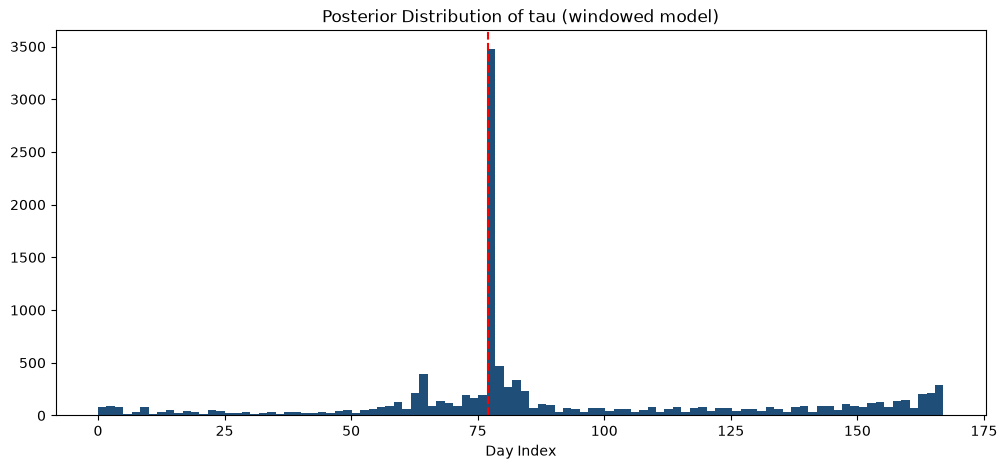

In [25]:
plt.hist(tau_samples, bins=100, color="#1F4E79")
plt.axvline(most_likely_idx, color="red", linestyle="--")
plt.title("Posterior Distribution of tau (windowed model)")
plt.xlabel("Day Index")
plt.show()

Applying Bayesian change point detection to Brent oil prices in early-to-mid 2020, the model detects a statistically significant change point on April 22, 2020 — just two days after the researched 'COVID-19 Demand Collapse' event (April 20, 2020). The average daily price shifted from $23.90 before the change point to $27.35 after, an increase of 14.44%, with an 82.8% posterior probability that the shift represented a genuine increase in mean price behavior. This finding is consistent with the historic Saudi-Russia price war and COVID-19 demand shock driving Brent prices to multi-decade lows in April 2020, followed by the beginning of a gradual market recovery as production cuts and demand stabilization took hold